# 関数設計

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
import matplotlib
from scipy.stats import shapiro
import warnings
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

warnings.filterwarnings("ignore", category=FutureWarning)

# 日本語フォント設定
matplotlib.rcParams['font.family'] = 'Meiryo'



# --- 定数定義 ---
CATEGORY_COLUMNS = {
    'sus':     list(range(1, 11)),   # SUS 1–10
    'tam':     list(range(11, 14)),  # TAM 11–13
    'method_trust':   list(range(14, 18)),  # Trust 14–17
    'system_trust':  list(range(18, 29)),  # Trust2 18–28
    'nasa':    list(range(29, 35)),  # NASA-TLX 29–37
}
PARTICIPANT_COL = 38
CONDITION_COL   = 39
INVALID_IDS     = ['0', 'TEST', 'OLD_P1',"", "OLD_P2",  "P1_OLD","P2_OLD","P3_OLD","P4_OLD","P5_OLD","P6_OLD", ]

CONDITION_MAP = {
    1: "SpatialReference",
    2: "Pointing+SpatialReference",
    3: "Pointing",
    4: "Label"
}
 # 特定のIDのみを残す場合（必要なときにコメントアウトを外す）



# --- スコア計算 ---
def calc_sus_score(raw: list[int]) -> float:
    adj = [(s - 1) if i % 2 == 0 else (5 - s) for i, s in enumerate(raw)]
    return sum(adj) * 2.5

def compute_mean(vals: list[int]) -> float:
    return np.mean(vals)

def reverse_scoring(df: pd.DataFrame) -> pd.DataFrame:
    df['system_trust'] = df['system_trust'].apply(lambda v: [6 - x if i in (8,9) else x for i, x in enumerate(v)])
    df['nasa']   = df['nasa'].apply(lambda v: [6 - x if i == 3 else x for i, x in enumerate(v)])
    return df

# --- 統計検定用 ---
def run_kruskal(label: str, df: pd.DataFrame) -> tuple[float, float]:
    groups = [df[df['condition'] == c][label] for c in CONDITION_MAP.values()]
    return kruskal(*groups)

def check_normality(label: str, df: pd.DataFrame):
    print(f"\n🔍 正規性の検定（Shapiro-Wilk）: {label}")
    for cond in CONDITION_MAP.values():
        vals = df[df['condition'] == cond][label].dropna()  # ← NaNを除く
        n = len(vals)
        if n < 3:
            print(f"{label} - {cond}: ⚠ データ数不足（{n} 件）→ 検定スキップ")
            continue
        try:
            stat, p = shapiro(vals)
            mark = "✅ 正規性あり" if p > 0.05 else "❌ 正規性なし"
            print(f"{label} - {cond}: W={stat:.3f}, p={p:.4f} {mark}")
        except Exception as e:
            print(f"{label} - {cond}: ⚠ 検定失敗 ({e})")


# --- データ読み込み & 前処理 ---

def load_and_preprocess(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, encoding='utf-8')


    
    # 参加者ID・条件情報の処理
    df['participant_id'] = df.iloc[:, PARTICIPANT_COL].astype(str)
    df['condition'] = df.iloc[:, CONDITION_COL].astype(int)

    # 無効なID除外
    df = df[~df['participant_id'].isin(INVALID_IDS)]
 
    print(len(df["participant_id"]))
    # df = df[df['participant_id'].isin(["P3"])]
    print(len(df))
    df = df.reset_index(drop=True)

    # SUS, TAM, Trust, Trust2, NASA などのスコア用リスト列を作成
    for key, cols in CATEGORY_COLUMNS.items():
        df[key] = df.iloc[:, cols].apply(lambda r: r.astype(int).tolist(), axis=1)
    
    
    return df

def kruskal_eta_squared(H: float, k: int, n: int) -> float:
    return (H - k + 1) / (n - k)

# --- メイン ---
def main():
    # データ読み込み・前処理
    df = load_and_preprocess('SurvayResult.csv')
    df = reverse_scoring(df)

    # スコア DataFrame 作成
    metrics = {
        'SUS':     ('sus',    calc_sus_score, 0, 100),
        'TAM':     ('tam',    compute_mean,   1,   7),
        'MethodTrust':   ('method_trust',  compute_mean,   1,   7),
        'SystemTrust':  ('system_trust', compute_mean,   1,   7),
        'NASA-TLX':('nasa',   compute_mean,   1,   7),
    }
    dfs = {}
    for name, (key, func, ymin, ymax) in metrics.items():
        dfs[name] = pd.DataFrame({
            'participant_id': df['participant_id'],
            'condition':      df['condition'],
            name:              df[key].apply(func)
        })

    # 条件ラベル適用
    ordered_conditions = ["SpatialReference", "Pointing+SpatialReference", "Pointing", "Label"]
    for dfm in dfs.values():
        dfm['condition'] = dfm['condition'].map(CONDITION_MAP)

    # 🔽 条件の並び順を明示的に指定
    ordered_conditions = ["SpatialReference", "Pointing+SpatialReference", "Pointing", "Label"]
    for dfm in dfs.values():
        dfm['condition'] = pd.Categorical(dfm['condition'], categories=ordered_conditions, ordered=True)
    # 1. 基本プロット: 箱ひげ＋スウォーム & 平均±SEバー
    fig1, axes1 = plt.subplots(len(metrics), 2, figsize=(14, 5*len(metrics)))
    for i, (name, dfm) in enumerate(dfs.items()):
        ymin, ymax = metrics[name][2], metrics[name][3]
        # 箱ひげ＋スウォーム
        ax = axes1[i, 0]
        sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
        sns.swarmplot(data=dfm, x='condition', y=name, color='k', alpha=0.6, ax=ax)
        ax.set(title=f"{name} の条件別比較", ylim=(ymin, ymax))
        # 平均±SEバー
        ax2 = axes1[i, 1]
        means = dfm.groupby('condition')[name].mean()
        sems  = dfm.groupby('condition')[name].sem()
        ax2.bar(means.index, means, yerr=sems, capsize=5)
        ax2.set(title=f"{name} 平均 ± SE", ylim=(ymin, ymax))
    plt.tight_layout(); plt.suptitle('条件別ユーザビリティ・受容性評価', y=1.02)
    plt.savefig('survey_plots.png', dpi=300)

    # 2. 統計検定 & 結果表示
    print()
    stats = {}
    for name in ['SUS','TAM','MethodTrust','SystemTrust']:
        stat, p = run_kruskal(name, dfs[name])
        has_significance = p < 0.05
        mark = "✅ 有意差あり" if has_significance else "❌ 有意差なし"
        print(f"{name}: H={stat:.3f}, p={p} {mark}")
        stats[name] = (stat, p)

        # 有意差があればDunn事後検定
        if has_significance:
            print("→ Dunnの事後検定（Bonferroni補正）結果:")
            print(sp.posthoc_dunn(dfs[name], val_col=name, group_col='condition', p_adjust='bonferroni'))
            print()
    # 各条件（行） × 各指標（列）の平均スコアを作成
    summary = pd.DataFrame(
    {
        metric: [
            dfs[metric][dfs[metric]['condition'] == cond][metric].mean()
            for cond in CONDITION_MAP.values()
        ]
        for metric in ['SUS', 'TAM', 'MethodTrust', 'SystemTrust']
    },
        index=CONDITION_MAP.values()  # 行名を条件のラベルに
    )

    # 小数点以下2桁で丸めて表示
    print(summary.round(2))

    # 4. 効果量 η² を表示
    print("\n効果量 η²（Kruskal-Wallis）:")
    for name in ['SUS','TAM','Trust','SystemTrust']:
        H, p = stats[name]
        n = len(dfs[name])  # データ数（NaN除外してないならOK）
        k = dfs[name]['condition'].nunique()
        eta2 = kruskal_eta_squared(H, k, n)
        print(f"{name}: η² = {eta2:.3f}")

    
    run_friedman_nemenyi(dfs)

    # 3. 統計結果付きボックスプロット
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
    for ax, name in zip(axes2.flat, ['SUS','TAM','MethodTrust','SystemTrust']):
        dfm = dfs[name]
        stat, p = stats[name]
        sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
        ax.set_title(f"{name} (H={stat:.2f}, p={p})")
        ax.set_xlabel(''); ax.set_ylabel(name)
    plt.tight_layout(); plt.suptitle('統計検定結果付き分布図', y=1.02)
    plt.savefig('stats_boxplots.png', dpi=300)
    plt.show()



In [124]:


from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import itertools

def run_friedman_nemenyi(dfs, alpha=.05):

    results = {}

    for metric, dfm in dfs.items():         # ← ループを dfs のキーに合わせても OK
        wide = dfm.pivot(index='participant_id',
                         columns='condition',
                         values=metric).dropna()
        try:
            stat, p = friedmanchisquare(*[wide[c] for c in wide.columns])
        except Exception as e:
            print(f"{metric}: Friedman error → {e}")
            continue

        print(f"{metric}: χ²={stat:.3f}, p={p:.4f}")
        if p >= alpha:
            continue        # 有意差なければスキップ

        # ---- Nemenyi ----
        post = sp.posthoc_nemenyi_friedman(wide)
        sig_pairs = []
        sig_pvals = []
        for i, j in itertools.combinations(range(len(post)), 2):
            pval = post.iloc[i, j]
            if pval < alpha:
                a = post.index[i]
                b = post.columns[j]
                sig_pairs.append((a, b))
                sig_pvals.append(pval)

        # results[metric] = dict(pairs=sig_pairs, pvals=sig_pvals)
        results[metric] = post 

    return results



import math
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_nemenyi_heatmaps(nemenyi_results: dict,
                               max_cols: int = 3,
                               figsize_per_ax: tuple = (6, 5)):
    """
    nemenyi_results : {'SUS':df, 'TAM':df, ...}
      → df は Nemenyi の p 値マトリクス (DataFrame)
    max_cols        : 1 行に並べる最大列数
    figsize_per_ax  : (横,縦) 1 枚あたりのサイズ
    """
    n = len(nemenyi_results)
    if n == 0:
        print("⚠ Nemenyi結果が空です")
        return

    # 行数・列数を自動決定
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)

    fig_w  = figsize_per_ax[0] * ncols
    fig_h  = figsize_per_ax[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h),
                             squeeze=False)  # 常に 2D 配列

    # flatten して for ループ
    axes_flat = axes.flatten()

    for ax, (metric, df) in zip(axes_flat, nemenyi_results.items()):
        sns.heatmap(df, annot=True, fmt=".3f", cmap="coolwarm_r",
                    cbar_kws=dict(label="p 値"),
                    linewidths=.5, square=True, ax=ax,
                    vmin=0, vmax=1)
        ax.set_title(f"{metric}  Nemenyi")

    # 余った空 ax を消す
    for ax in axes_flat[len(nemenyi_results):]:
        ax.axis("off")

    plt.suptitle("Nemenyi 事後検定結果ヒートマップ", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig("nemenyi_heatmaps.png", dpi=300, bbox_inches="tight")
    plt.show()


In [22]:
# main()

In [23]:
df['condition'] = df['condition'].map(CONDITION_MAP)

# データ読み込み・前処理

In [108]:
import re 
# データ読み込み・前処理
df_result = load_and_preprocess('SurvayResult.csv')
df_result = reverse_scoring(df_result)

INVALID_IDS     = ['0', 'TEST', 'OLD_P1',"", "OLD_P2",  "P1_OLD","P2_OLD","P3_OLD","P4_OLD","P5_OLD","P6_OLD", ]
df_result = df_result[~df_result['participant_id'].isin(INVALID_IDS)]
CATEGORY_COLUMNS = {
    'sus':     list(range(1, 11)),   # SUS 1–10
    'tam':     list(range(11, 14)),  # TAM 11–13
    'method_trust':   list(range(14, 18)),  # Trust 14–17
    'system_trust':  list(range(18, 29)),  # Trust2 18–28
    'nasa':    list(range(29, 35)),  # NASA-TLX 29–37
}
survay_score  = {}
survay_questions = {}

for key, cols in CATEGORY_COLUMNS.items():
    # スライスは cols[0] から cols[-1]+1 まで（末尾を含むには+1が必要）
    cleaned_columns = [re.sub(r'\n（.*?）', '', col) for col in df_result.columns[cols[0]:cols[-1]+1]]
    survay_questions[key] = cleaned_columns


for key, cols in CATEGORY_COLUMNS.items():
    survay_score[key] = df_result.iloc[:, cols].apply(lambda r: r.astype(int).tolist(), axis=1)




# スコア DataFrame 作成
metrics = {
    'SUS':     ('sus',    calc_sus_score, 0, 100),
    'TAM':     ('tam',    compute_mean,   1,   7),
    'MethodTrust':   ('method_trust',  compute_mean,   1,   7),
    'SystemTrust':  ('system_trust', compute_mean,   1,   7),
    'NASA-TLX':('nasa',   compute_mean,   1,   7),
}
dfs = {}
for name, (key, func, ymin, ymax) in metrics.items():
    dfs[name] = pd.DataFrame({
        'participant_id': df_result['participant_id'],
        'condition':      df_result['condition'],
        name:              df_result[key].apply(func)
    })

# 条件ラベル適用
ordered_conditions = ["SpatialReference", "Pointing+SpatialReference", "Pointing", "Label"]
for dfm in dfs.values():
    dfm['condition'] = dfm['condition'].map(CONDITION_MAP)

96
96


# 結果の可視化

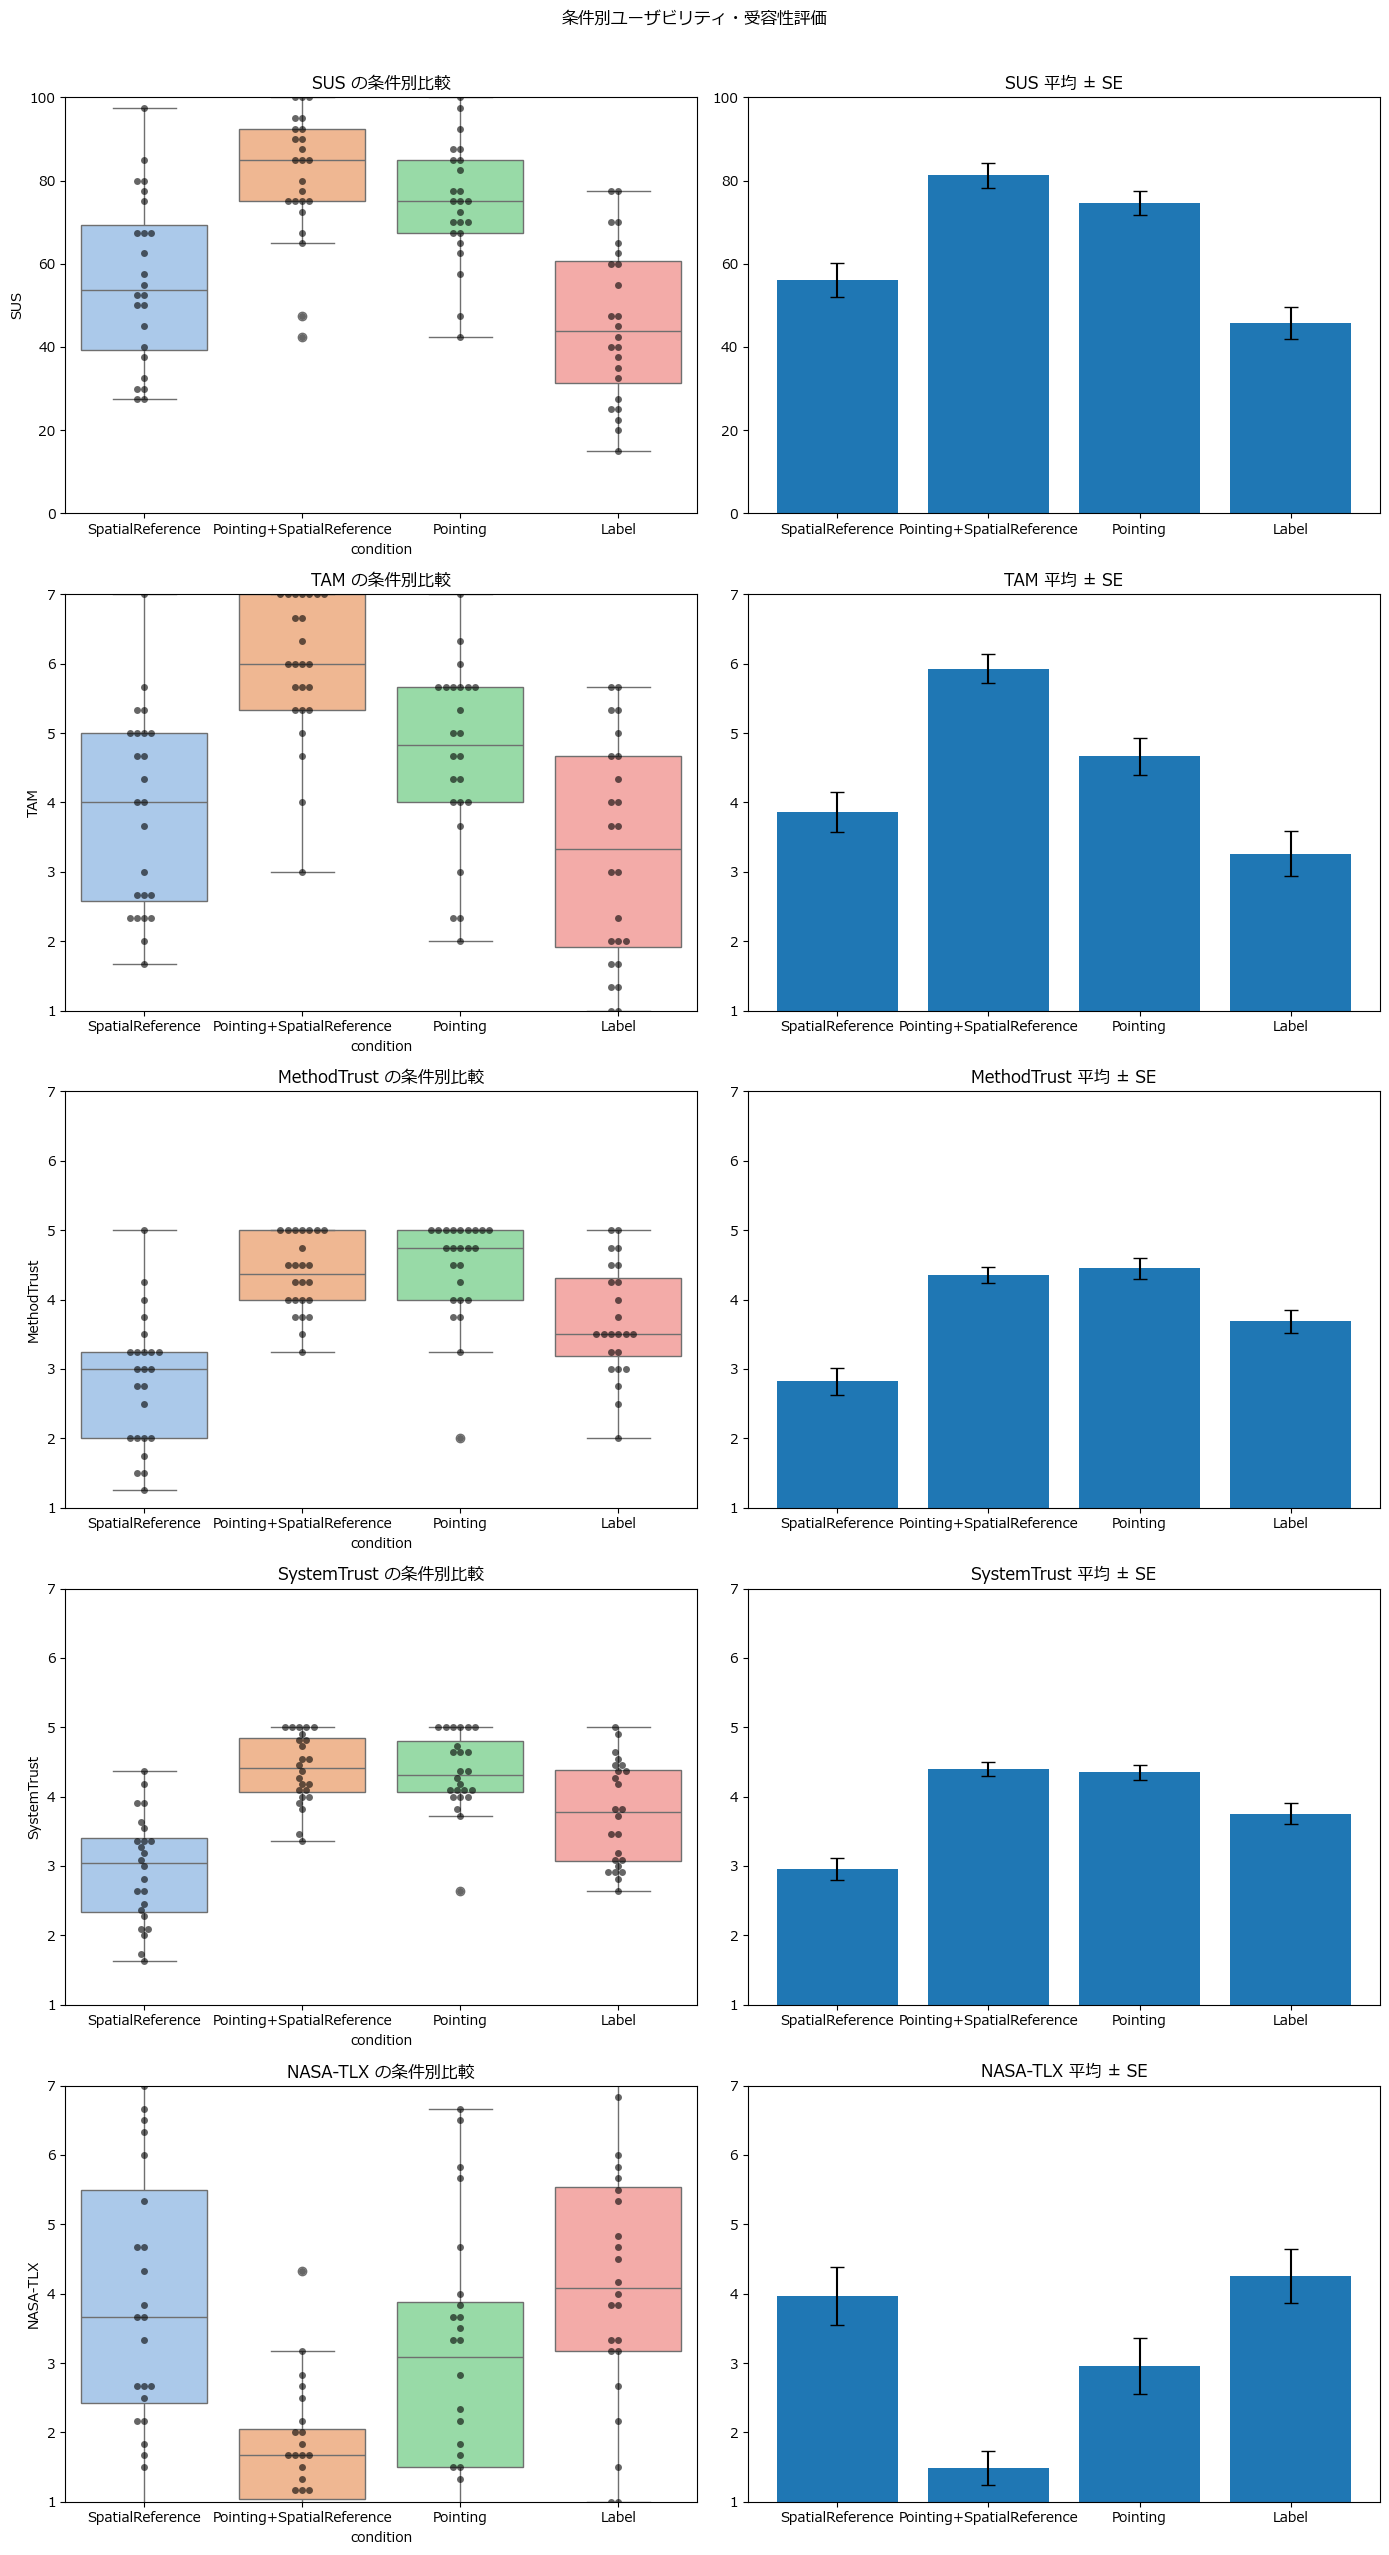

In [11]:
# 🔽 条件の並び順を明示的に指定
ordered_conditions = ["SpatialReference", "Pointing+SpatialReference", "Pointing", "Label"]
for dfm in dfs.values():
    dfm['condition'] = pd.Categorical(dfm['condition'], categories=ordered_conditions, ordered=True)
# 1. 基本プロット: 箱ひげ＋スウォーム & 平均±SEバー
fig1, axes1 = plt.subplots(len(metrics), 2, figsize=(14, 5*len(metrics)))
for i, (name, dfm) in enumerate(dfs.items()):
    ymin, ymax = metrics[name][2], metrics[name][3]
    # 箱ひげ＋スウォーム
    ax = axes1[i, 0]
    sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
    sns.swarmplot(data=dfm, x='condition', y=name, color='k', alpha=0.6, ax=ax)
    ax.set(title=f"{name} の条件別比較", ylim=(ymin, ymax))
    # 平均±SEバー
    ax2 = axes1[i, 1]
    means = dfm.groupby('condition')[name].mean()
    sems  = dfm.groupby('condition')[name].sem()
    ax2.bar(means.index, means, yerr=sems, capsize=5)
    ax2.set(title=f"{name} 平均 ± SE", ylim=(ymin, ymax))
plt.tight_layout(); plt.suptitle('条件別ユーザビリティ・受容性評価', y=1.02)
plt.savefig('survey_plots.png', dpi=300)


# Friedman統計検定・結果

SUS: χ²=44.161, p=0.0000
TAM: χ²=32.429, p=0.0000
MethodTrust: χ²=39.968, p=0.0000
SystemTrust: χ²=43.349, p=0.0000
NASA-TLX: χ²=32.046, p=0.0000


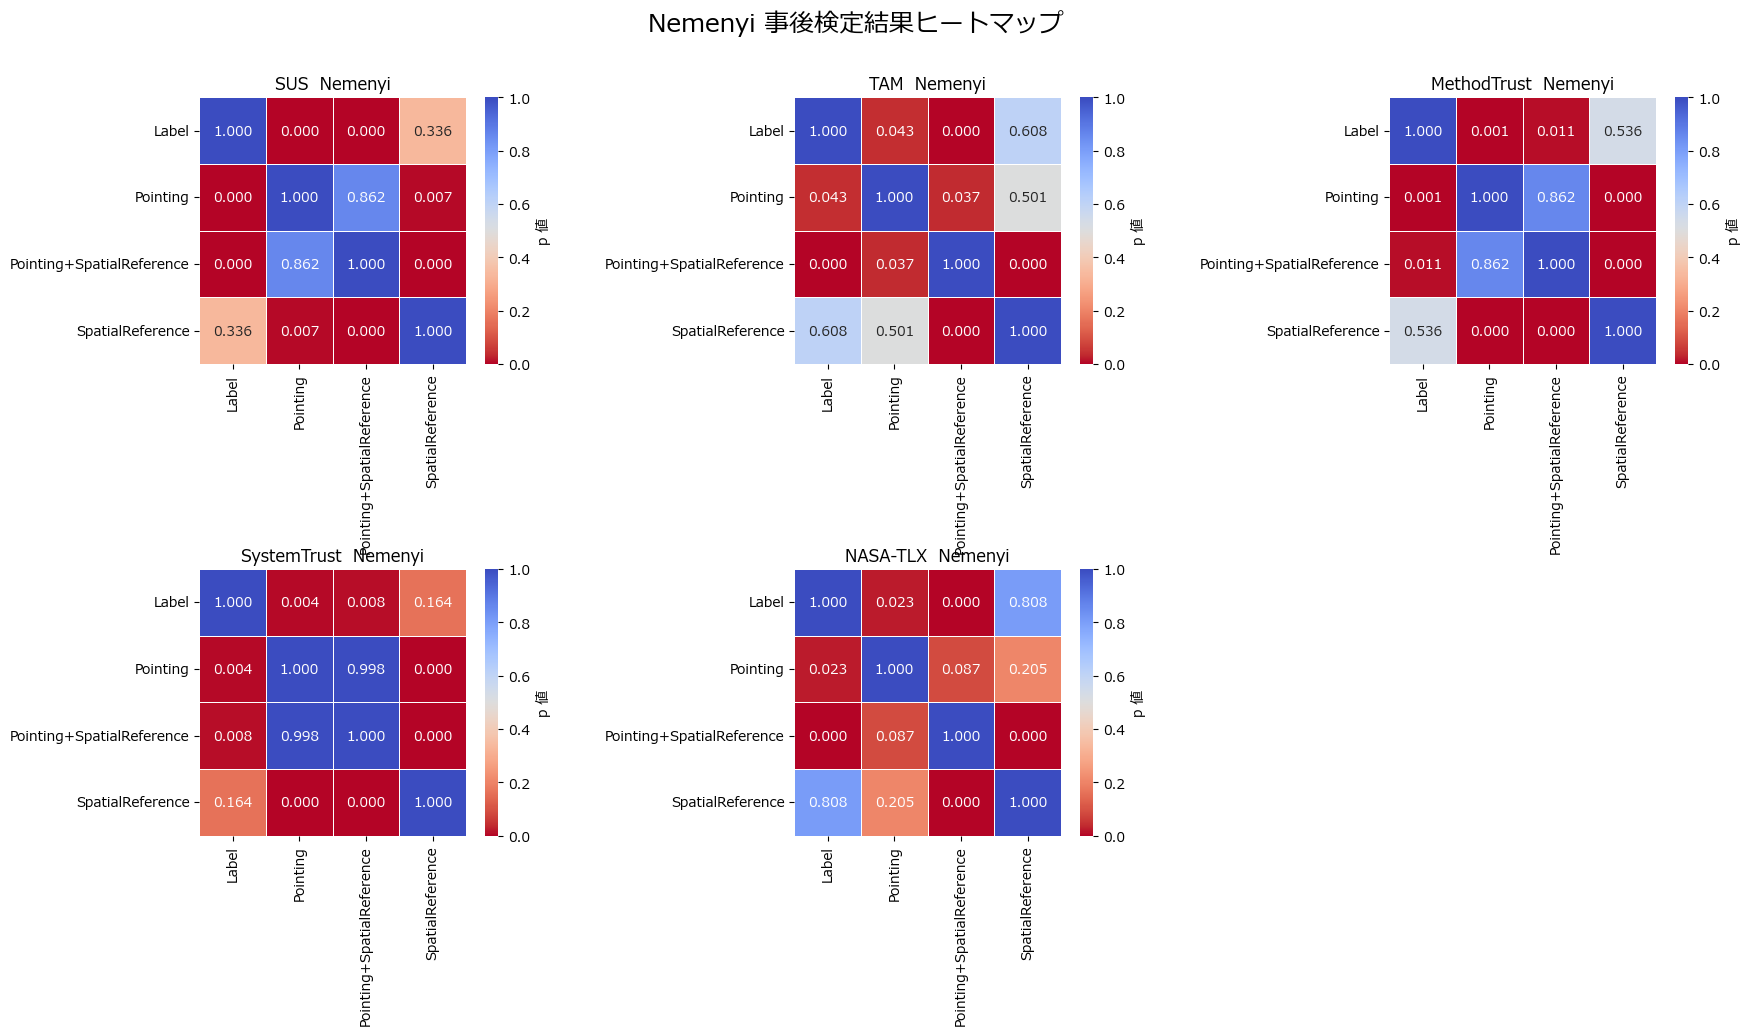

In [126]:
nemenyi_results = run_friedman_nemenyi(dfs)  # ← 結果を受け取る
visualize_nemenyi_heatmaps(nemenyi_results, figsize_per_ax=(6, 5))


In [117]:
col = df_result.columns[CATEGORY_COLUMNS['sus'][i]]
df_result[df_result[col].isna()]

TypeError: list indices must be integers or slices, not str

In [120]:
sus_results = run_friedman_nemenyi_per_question(
    df_result=df_result,
    category_name='SUS',
    condition_order=ordered_conditions,
    category_cols=CATEGORY_COLUMNS['sus'],
    question_names=survay_questions['sus']
)
sus_results

{}

In [68]:

print(survay_score["sus"])


0     [2, 1, 4, 1, 5, 1, 5, 2, 2, 1]
1     [5, 1, 5, 1, 5, 1, 5, 1, 5, 1]
2     [4, 4, 5, 1, 5, 1, 5, 2, 5, 1]
3     [4, 1, 5, 1, 5, 1, 3, 2, 4, 5]
4     [4, 2, 4, 3, 4, 1, 4, 3, 4, 4]
                   ...              
91    [5, 1, 5, 2, 5, 2, 5, 2, 5, 2]
92    [2, 2, 4, 2, 3, 2, 3, 2, 4, 2]
93    [2, 4, 2, 4, 3, 4, 2, 4, 2, 3]
94    [4, 2, 4, 2, 4, 2, 4, 2, 4, 2]
95    [4, 2, 5, 2, 3, 2, 5, 2, 4, 2]
Length: 96, dtype: object


ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install


In [355]:

def plot_likert_matrix(
    dfs,
    question_cols,
    titles=None,
    likert_colors=None,
    likert_labels=None,
    ncols=2,
    subplot_size=(8, 4),  # CHANGE: New parameter to define the size (width, height) of each subplot.
    main_title=None,
    condition_order=['DeviceFilter+Spatial', 'Pointing+Spatial', 'Pointing Only', 'Label']
):
    """
    条件別 Likert 回答結果を横棒スタックで可視化（SUS, TAM, Trust などに汎用）
    - This version ensures a fixed size for each subplot.
    """

    # --- Default settings (common style) ---
    if likert_colors is None:
        likert_colors = [
            '#d4b3ff',  # Strongly Disagree
            '#e6ccff',  # Disagree
            '#add8e6',  # Neutral
            '#5dade2',  # Agree
            '#2e86c1'   # Strongly Agree
        ]
    if likert_labels is None:
        likert_labels = {1: 'Strongly Disagree', 2: 'Disagree', 3: 'Neutral', 4: 'Agree', 5: 'Strongly Agree'}
    if titles is None:
        titles = {q: f"{q}" for q in question_cols}

    # --- CHANGE: Dynamic figsize calculation ---
    # Calculate the number of rows required.
    nrows = int(np.ceil(len(question_cols) / ncols))
    # Get the desired width and height for a single subplot.
    subplot_width, subplot_height = subplot_size
    # Calculate the total figure size needed to maintain the subplot size.
    figsize = (ncols * subplot_width, nrows * subplot_height)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    # Ensure 'axes' is always a flat array for easy iteration, even with one plot.
    if len(question_cols) > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, q in enumerate(question_cols):
        ax = axes[i]
        

        # Aggregate response counts for each condition
        summary = pd.DataFrame(0, index=dfs.keys(), columns=[1, 2, 3, 4, 5])
        for cond, df_result in dfs.items():
            vc = df_result[q].value_counts()
            for val in [1, 2, 3, 4, 5]:
                summary.loc[cond, val] = vc.get(val, 0)
        
        # Ensure the summary is in the specified order
        summary = summary.reindex(condition_order)

        # Plot horizontal stacked bar chart
        summary.plot(
            kind='barh',
            stacked=True,
            color=likert_colors,
            ax=ax,
            width=0.8,
            legend=False
        )

        ax.set_title(f"Q{i+1}: {titles.get(q, q)}", fontsize=14)
        ax.set_xlabel("Number of Responses")
        ax.set_ylabel('')
        ax.invert_yaxis()
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='y', labelsize=12)

        # --- Significance testing and plotting ---
        stat, p, n, sig_pairs = run_friedman_with_posthoc(q, dfs, condition_order)
        if p is not None and p < 0.05:
            if sig_pairs:
                sig_pairs = sorted(sig_pairs, key=lambda x: x[2], reverse=True)
                index_pairs = [(condition_order.index(a), condition_order.index(b)) for a, b, _ in sig_pairs]
                ranks = assign_interval_ranks(index_pairs)

                for j, (a, b, pv) in enumerate(sig_pairs):
                    row1 = summary.index.get_loc(a)
                    row2 = summary.index.get_loc(b)
                    x_brkt = summary.sum(axis=1).max()  # Position brackets to the right
                    
                    if pv < 0.01:
                        draw_significance_bracket(ax, row1, row2, x_start=x_brkt, single=False, count=ranks[j])
                    elif pv < 0.05:
                        draw_significance_bracket(ax, row1, row2, x_start=x_brkt, single=True, count=ranks[j])
            else:
                print(f"   ⏭ For Q '{q}': Significant difference found, but post-hoc test did not detect specific pairs")
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Draw a single, shared legend at the bottom
    if len(question_cols) > 0:
        handles, labels_ = axes[0].get_legend_handles_labels()
        labels_ = [likert_labels[int(l)] for l in labels_]
        fig.legend(
            handles, labels_,
            loc='lower center',
            ncol=5,
            bbox_to_anchor=(0.5, 0.01),
            fontsize=12,
            frameon=False
        )

    if main_title:
        fig.suptitle(main_title, fontsize=20, y=0.99)

    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()


In [356]:
df_result = load_and_preprocess('SurvayResult.csv')
df_result = reverse_scoring(df_result)

INVALID_IDS     = ['0', 'TEST', 'OLD_P1',"", "OLD_P2",  "P1_OLD","P2_OLD","P3_OLD","P4_OLD","P5_OLD","P6_OLD", ]
df_result = df_result[~df_result['participant_id'].isin(INVALID_IDS)]



96
96


### SUS

NameError: name 'get_cmap' is not defined

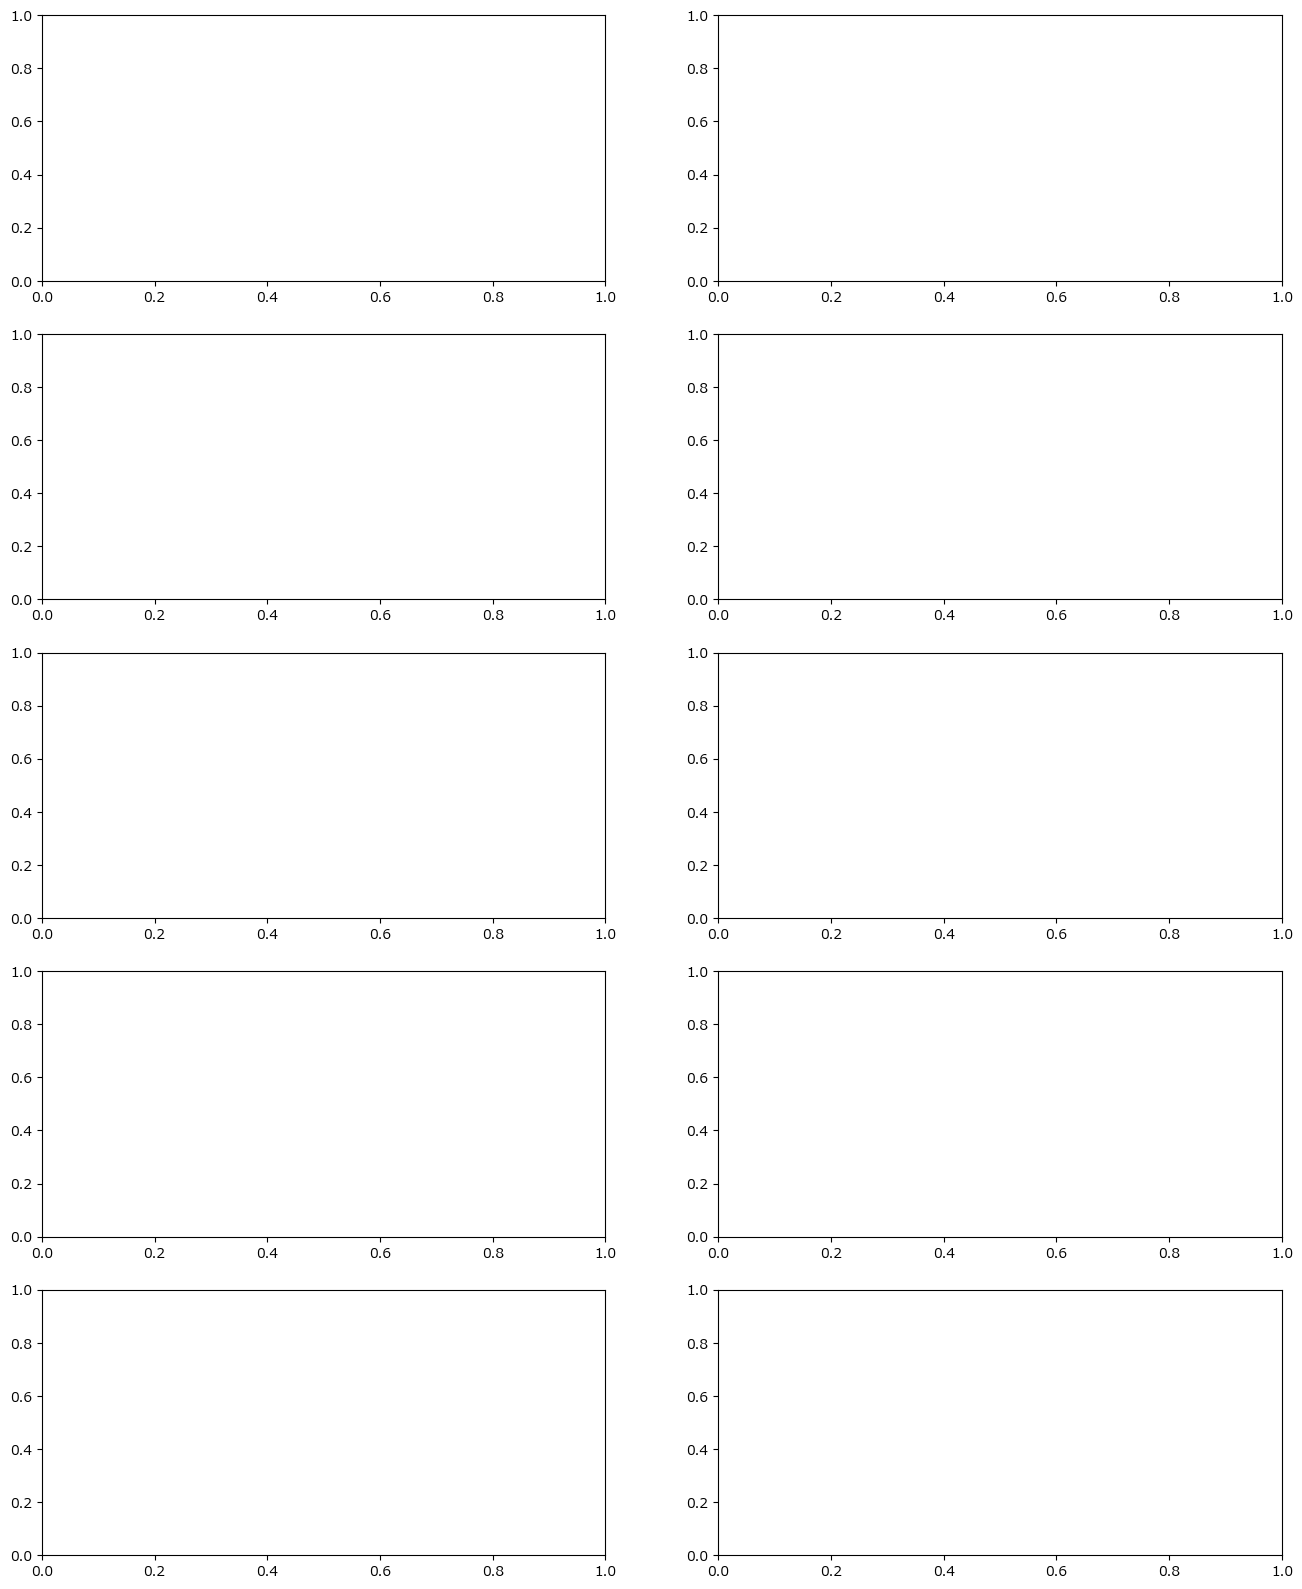

In [357]:
 
# Condition の値と DataFrame 名の対応例
# 1: DeviceFilterAgent + SpatialReasoningAgent → df_spatial
# 2: Pointing + SpatialReasoningAgent      → df_ptSpatial
# 3: Pointing Only                         → df_point
# 4: Label                                 → df_label

df_spatial    = df_result[df_result['Condition'] == 1].copy()
df_ptSpatial  = df_result[df_result['Condition'] == 2].copy()
df_point      = df_result[df_result['Condition'] == 3].copy()
df_label      = df_result[df_result['Condition'] == 4].copy()

sus_cols = df_result.columns[1:11]


# Condition ごとに分けた各 DataFrame から、SUS スコア部分だけを取り出す
df_spatial_sus   = df_spatial.iloc[:, 1:11].copy()
df_ptSpatial_sus = df_ptSpatial.iloc[:, 1:11].copy()
df_point_sus     = df_point.iloc[:, 1:11].copy()
df_label_sus     = df_label.iloc[:, 1:11].copy()

dfs = {
    'DeviceFilter+Spatial':   df_spatial_sus,
    'Pointing+Spatial':       df_ptSpatial_sus,
    'Pointing Only':          df_point_sus,
    'Label':                  df_label_sus
}

plot_likert_matrix(
    dfs=dfs,
    question_cols=sus_cols,
    main_title="SUS Responses by Condition"
)

### TAM 

In [ ]:
# 質問列 index の取得
tam_cols = df_result.columns[CATEGORY_COLUMNS['tam']]

# 各条件ごとの該当列だけ抽出
df_spatial_tam   = df_spatial[tam_cols].copy()
df_ptSpatial_tam = df_ptSpatial[tam_cols].copy()
df_point_tam     = df_point[tam_cols].copy()
df_label_tam     = df_label[tam_cols].copy()

# 辞書にまとめる
dfs_tam = {
    'DeviceFilter+Spatial':   df_spatial_tam,
    'Pointing+Spatial':       df_ptSpatial_tam,
    'Pointing Only':          df_point_tam,
    'Label':                  df_label_tam
}

# プロット
plot_likert_matrix(
    dfs=dfs_tam,
    question_cols=tam_cols,
    main_title="TAM Responses by Condition"
)


In [349]:
for name, df in dfs_tam.items():
    print(f"{name}: {len(df)} rows")

DeviceFilter+Spatial: 24 rows
Pointing+Spatial: 24 rows
Pointing Only: 24 rows
Label: 24 rows


### MethodTrust

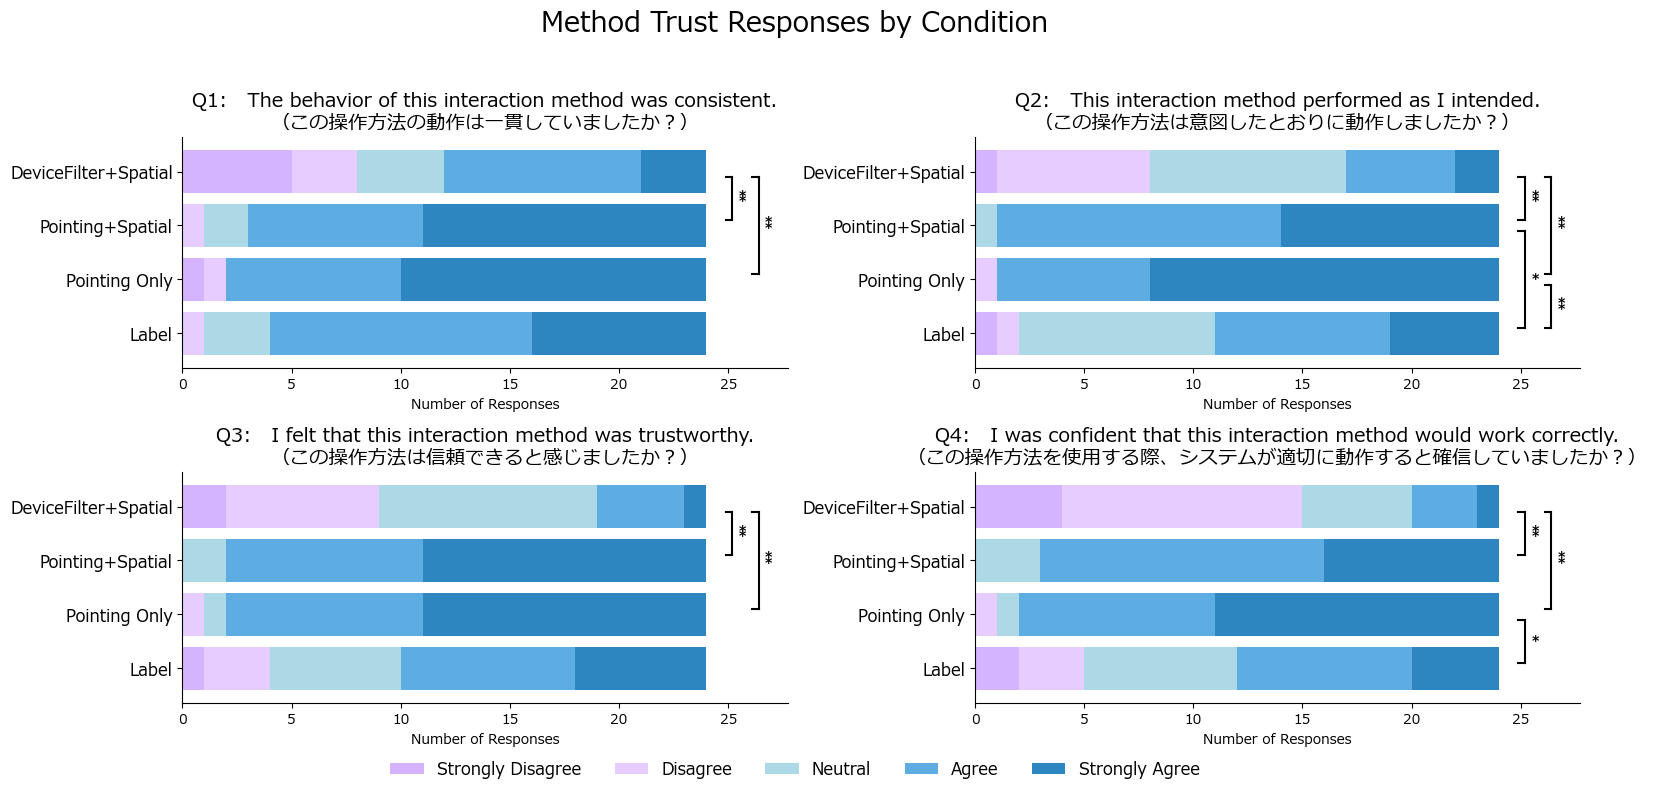

In [339]:
# 質問列 index の取得
method_trust_cols = df_result.columns[CATEGORY_COLUMNS['method_trust']]

# 各条件ごとの該当列だけ抽出
df_spatial_method_trust   = df_spatial[method_trust_cols].copy()
df_ptSpatial_method_trust = df_ptSpatial[method_trust_cols].copy()
df_point_method_trust     = df_point[method_trust_cols].copy()
df_label_method_trust     = df_label[method_trust_cols].copy()

# 辞書にまとめる
dfs_method_trust = {
    'DeviceFilter+Spatial':   df_spatial_method_trust,
    'Pointing+Spatial':       df_ptSpatial_method_trust,
    'Pointing Only':          df_point_method_trust,
    'Label':                  df_label_method_trust
}

# プロット
plot_likert_matrix(
    dfs=dfs_method_trust,
    question_cols=method_trust_cols,
    main_title="Method Trust Responses by Condition"
)


### System Trust

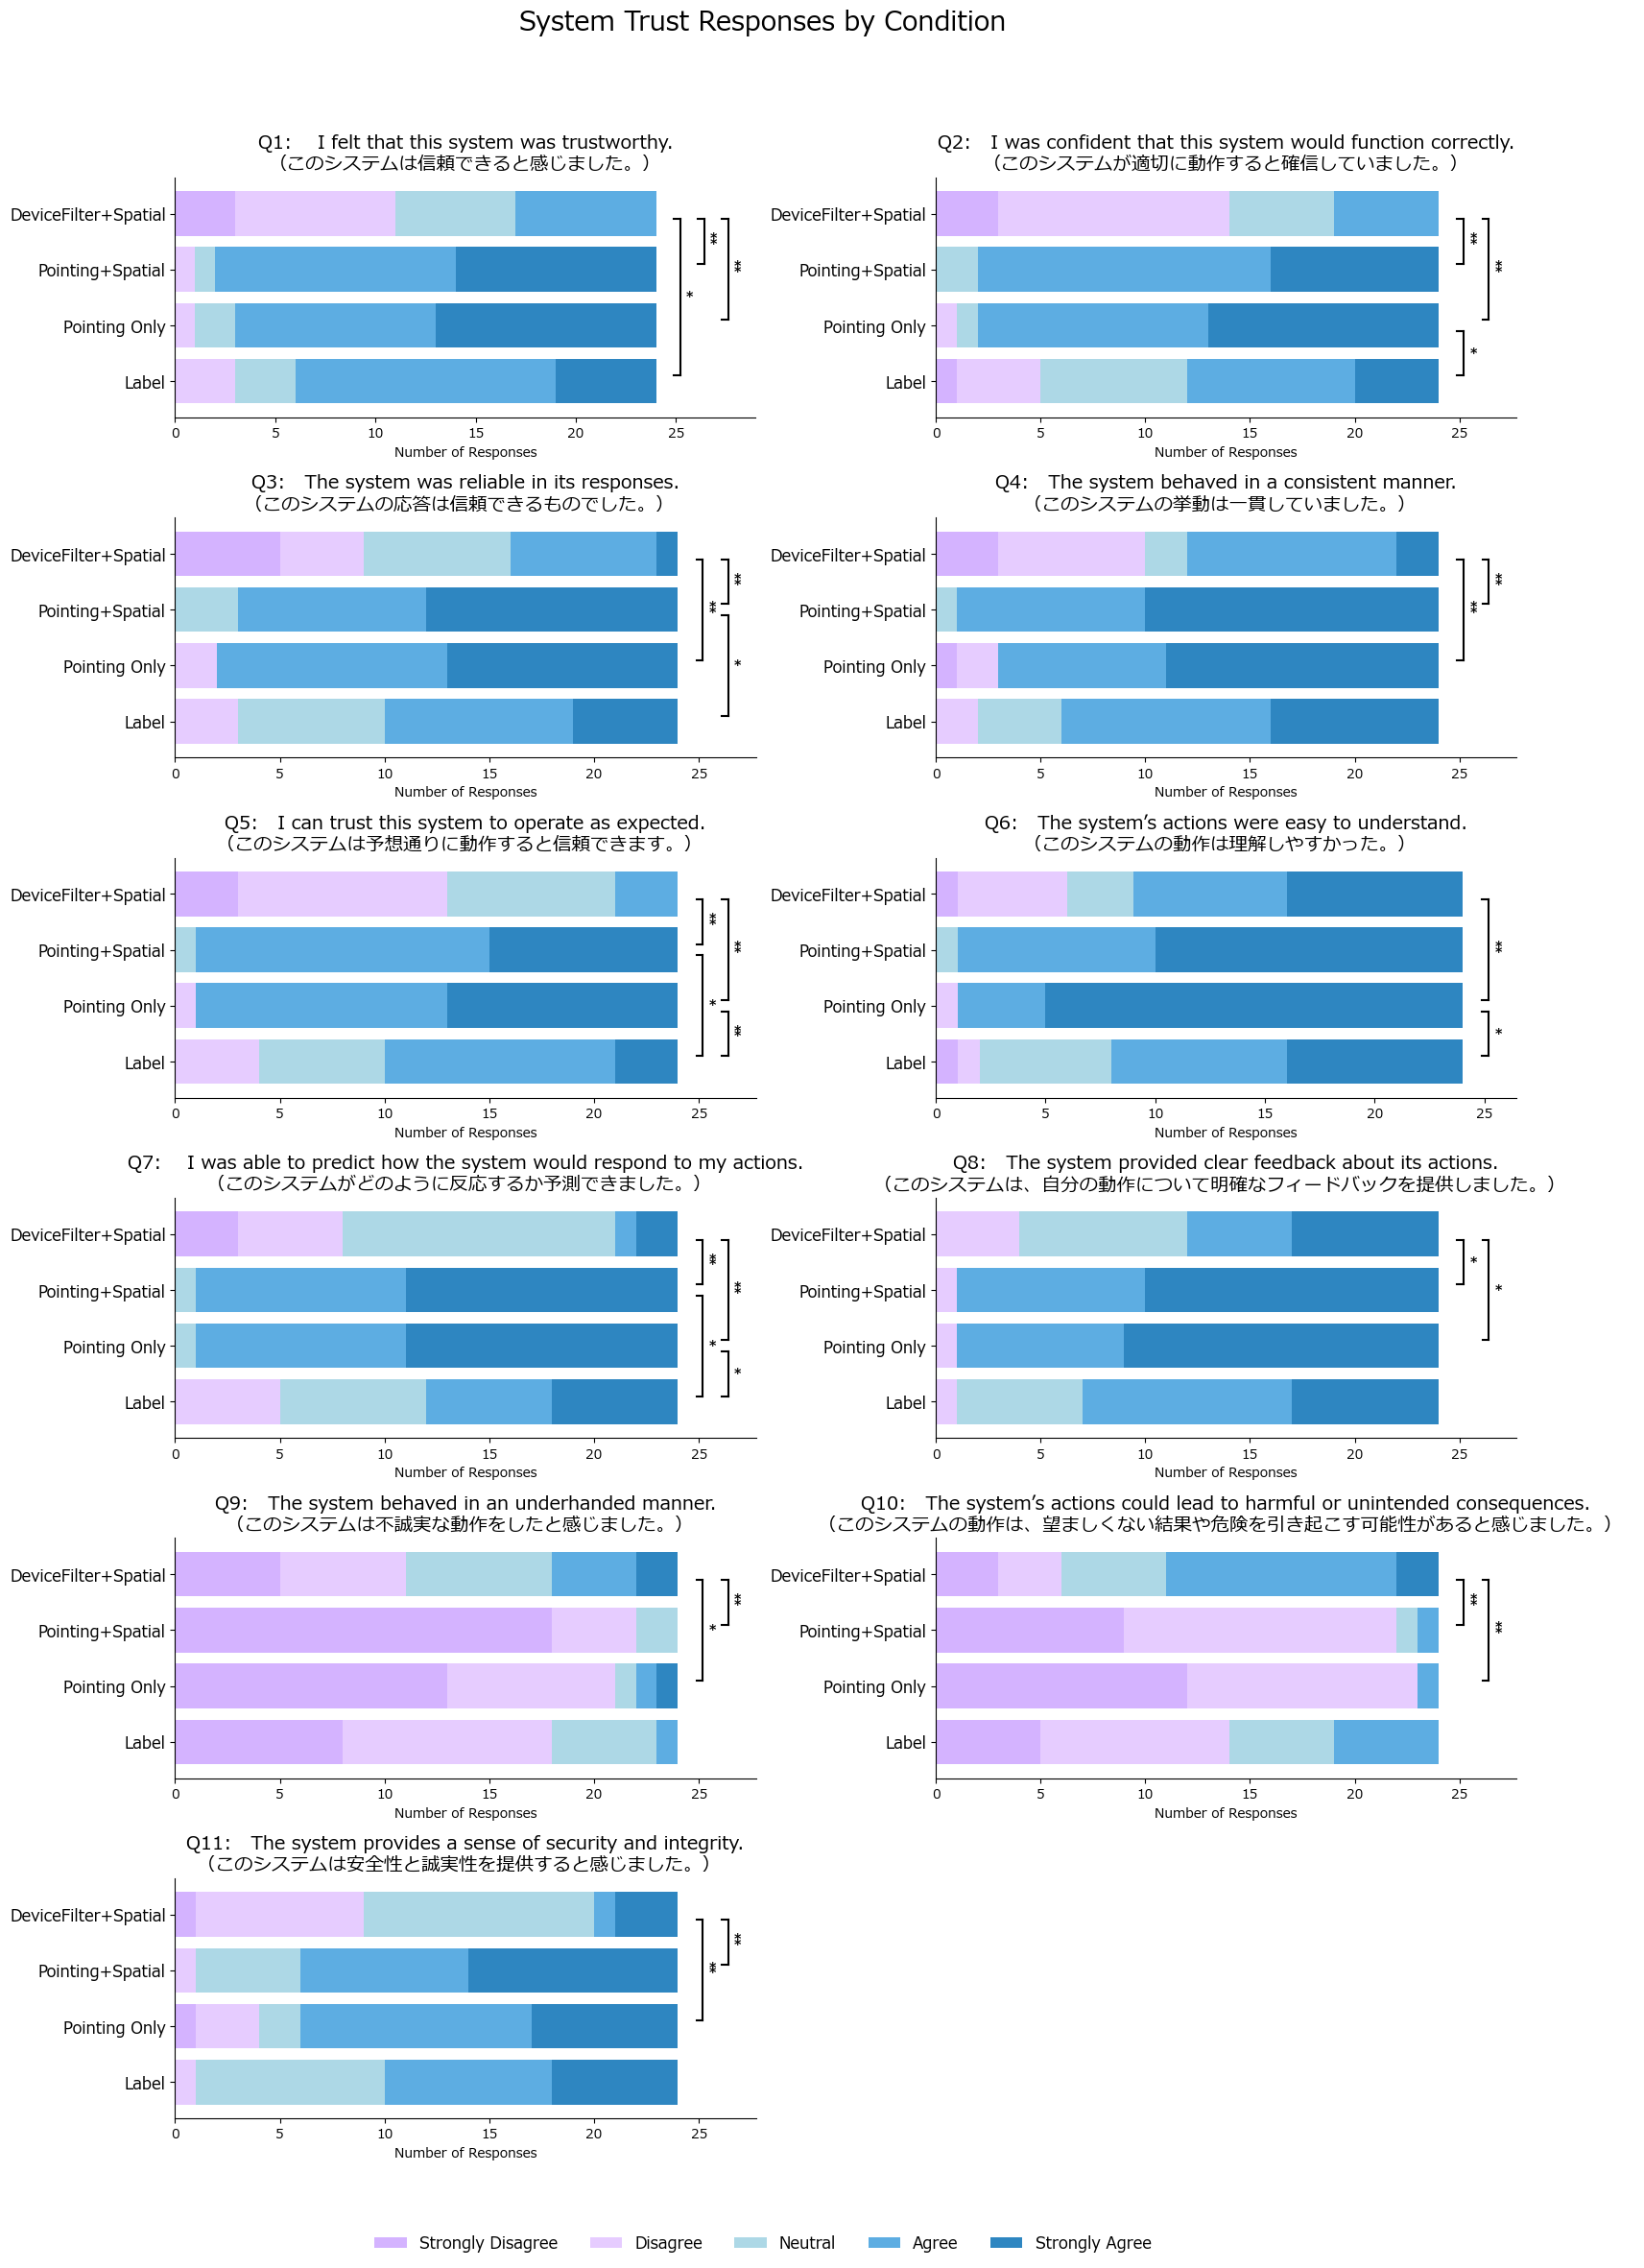

In [340]:
system_trust_cols = df_result.columns[CATEGORY_COLUMNS['system_trust']]

df_spatial_system_trust   = df_spatial[system_trust_cols].copy()
df_ptSpatial_system_trust = df_ptSpatial[system_trust_cols].copy()
df_point_system_trust     = df_point[system_trust_cols].copy()
df_label_system_trust     = df_label[system_trust_cols].copy()

dfs_system_trust = {
    'DeviceFilter+Spatial':   df_spatial_system_trust,
    'Pointing+Spatial':       df_ptSpatial_system_trust,
    'Pointing Only':          df_point_system_trust,
    'Label':                  df_label_system_trust
}

plot_likert_matrix(
    dfs=dfs_system_trust,
    question_cols=system_trust_cols,
    main_title="System Trust Responses by Condition"
)


### NASA-TLX

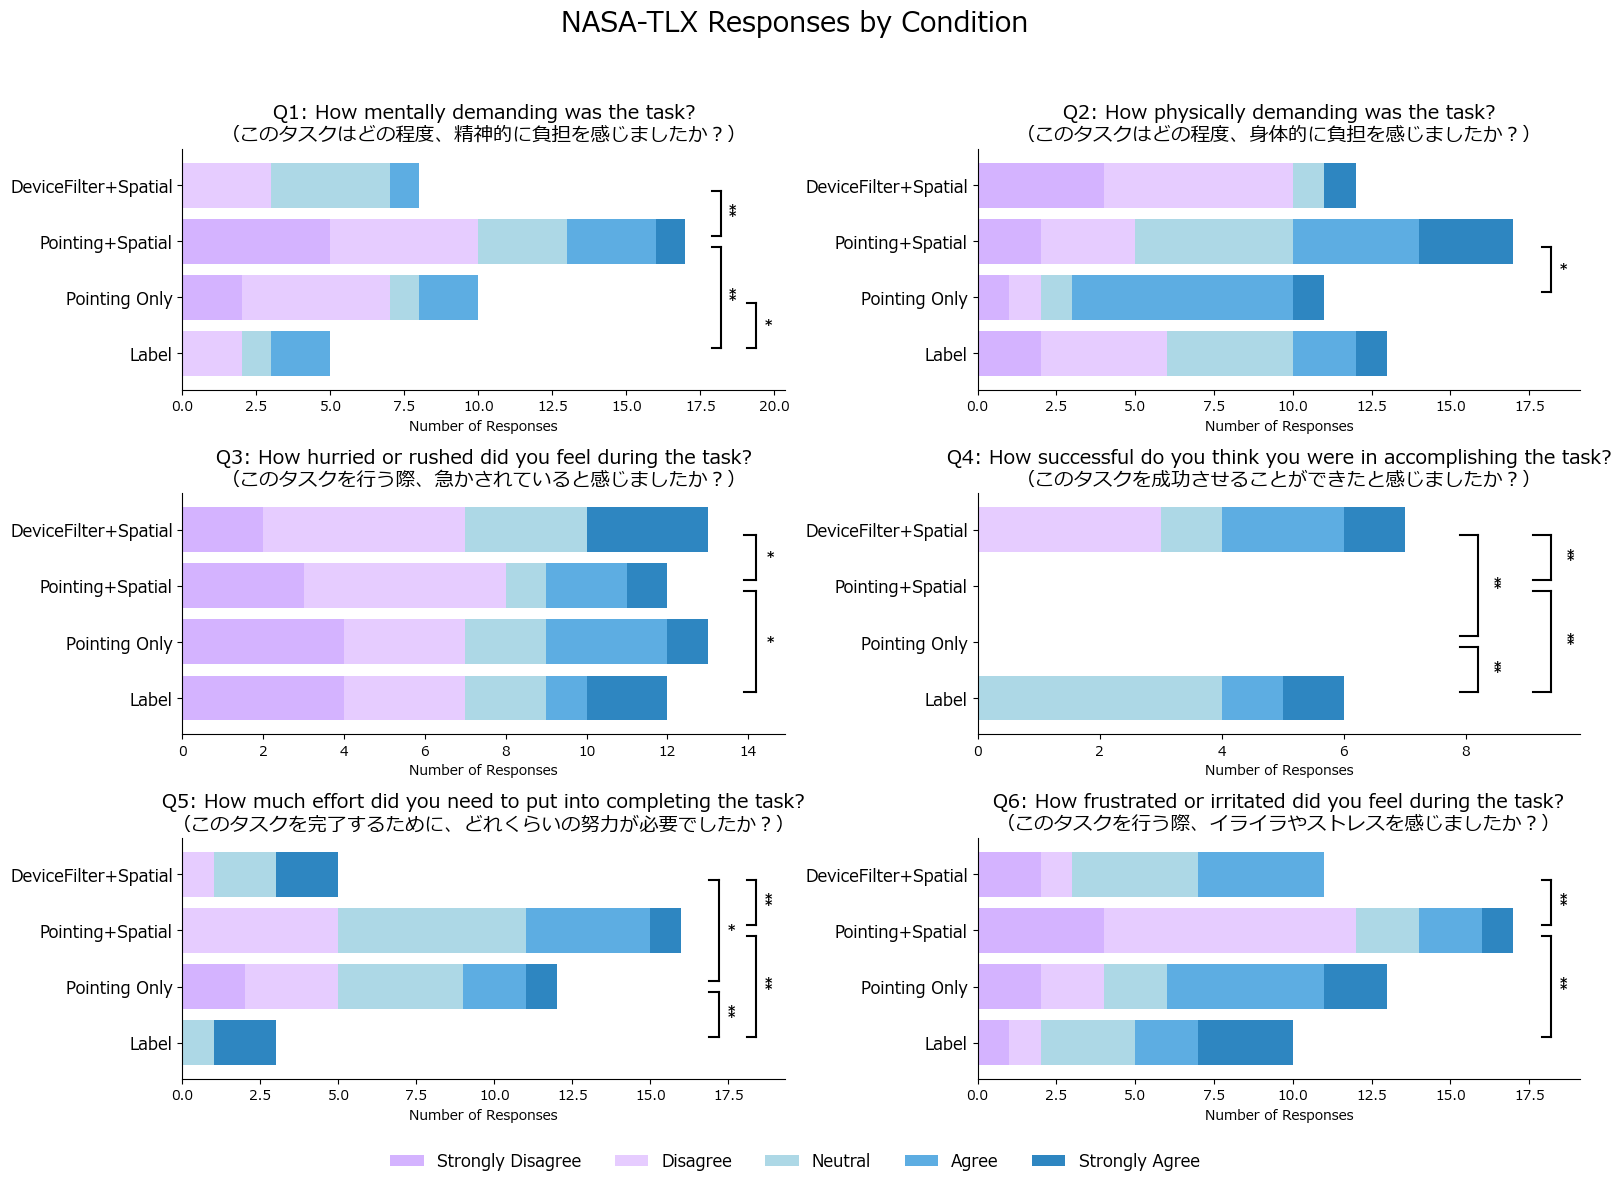

In [341]:
nasa_cols = df_result.columns[CATEGORY_COLUMNS['nasa']]

dfs_nasa = {
    'DeviceFilter+Spatial':   df_spatial[nasa_cols].copy(),
    'Pointing+Spatial':       df_ptSpatial[nasa_cols].copy(),
    'Pointing Only':          df_point[nasa_cols].copy(),
    'Label':                  df_label[nasa_cols].copy()
}

plot_likert_matrix(
    dfs=dfs_nasa,
    question_cols=nasa_cols,
    main_title="NASA-TLX Responses by Condition"
)


In [354]:
ind = 32
print(df_result.columns[ind]) 

q4_col = df_result.columns[ind] 
print(df_result.groupby("Condition")[q4_col].count())



# Q4 の列のユニークな型
q4_col = 'How successful do you think you were in accomplishing the task?\n（このタスクを成功させることができたと感じましたか？）'
print(df_result[q4_col].unique())
print(df_result[q4_col].apply(type).value_counts())

How successful do you think you were in accomplishing the task?
（このタスクを成功させることができたと感じましたか？）
Condition
1    24
2    24
3    24
4    24
Name: How successful do you think you were in accomplishing the task?\n（このタスクを成功させることができたと感じましたか？）, dtype: int64
[10  8  9  7  3  2  6  0  4  5]
How successful do you think you were in accomplishing the task?\n（このタスクを成功させることができたと感じましたか？）
<class 'int'>    96
Name: count, dtype: int64


In [279]:
def draw_significance_bracket(ax, row1, row2, x_start, bracket_width=0.3, single=True, count=0, fontsize=10):
    """
    横棒グラフ用の有意差ブラケット（完全に右外に描画・重なり防止対応）

    Parameters:
        ax: Axes
        row1, row2: 対象行のインデックス（小さい方が上）
        x_start: 一番内側のブラケットの開始x位置（棒グラフの右端より少し外側）
        bracket_width: 括弧の横幅
        single: True → "*", False → "**" の縦並び
        count: ブラケットの番号（0から順に渡す）
        fontsize: ラベルサイズ
    """

    # 🧠 全体のオフセット（ブラケットごとに右へずらす）
    offset_per_bracket = 1.2  # 調整可能
    base_x = x_start + count * offset_per_bracket

    # 縦線（ブラケット）
    ax.plot([base_x, base_x], [row1 + 0.1, row2 - 0.1], lw=1.5, color='k', clip_on=False)
    # 横線（下）
    ax.plot([base_x, base_x - bracket_width], [row1 + 0.1, row1 + 0.1], lw=1.5, color='k', clip_on=False)
    # 横線（上）
    ax.plot([base_x, base_x - bracket_width], [row2 - 0.1, row2 - 0.1], lw=1.5, color='k', clip_on=False)

    # ラベル
    label_x = base_x + bracket_width - 0.06  # ラベル位置はさらに右へ
    if single:
        ax.text(
            label_x,
            (row1 + row2) / 2,
            "*",
            ha='left',
            va='center',
            fontsize=fontsize,
            fontweight='bold'
        )
    else:
        ax.text(
            label_x,
            (row1 + row2 + 0.1) / 2,
            "*",
            ha='left',
            va='center',
            fontsize=fontsize,
            fontweight='bold'
        )
        ax.text(
            label_x,
            (row1 + row2 - 0.1) / 2,
            "*",
            ha='left',
            va='center',
            fontsize=fontsize,
            fontweight='bold'
        )


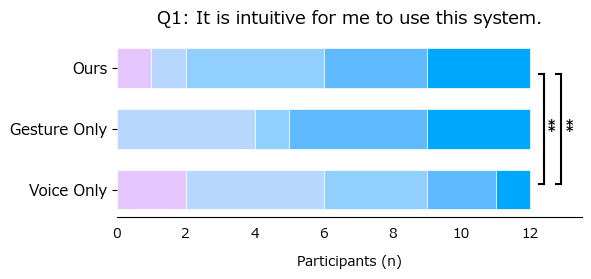

In [242]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. データ (例: 5 段階 Likert × 3 条件) ─────────────────────
labels = ['Ours', 'Gesture Only', 'Voice Only']
counts = np.array([
    [1, 1, 4, 3, 3],   # Ours
    [0, 4, 1, 4, 3],   # Gesture Only
    [2, 4, 3, 2, 1],   # Voice Only
])                    # 形状 = (条件, ラベル値ごとの個数)

colors = ['#e6c6ff', '#b7d7ff', '#91cfff', '#5fb9ff', '#00a7ff']  # 薄→濃

# ── 2. 横型スタックバーの描画 ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 2.3))
y_pos = np.arange(len(labels))

left = np.zeros(len(labels))
for i in range(counts.shape[1]):
    ax.barh(y_pos, counts[:, i], left=left,
            height=0.65, color=colors[i], edgecolor='w', linewidth=.5)
    left += counts[:, i]           # 次のスタック開始点を更新

# ── 3. 補助: 軸設定 ─────────|───────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11, ha='right')
ax.invert_yaxis()                  # 上が先頭になるよう反転
ax.set_xlim(0, counts.sum(1).max() + 1.5)  # 右側に括弧を置く余白
ax.set_xlabel('Participants (n)', labelpad=10)
ax.set_title('Q1: It is intuitive for me to use this system.', fontsize=13, pad=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.set_ticks_position('none')

# ── 4. 括弧( bracket )と星の描画 ─────────────────────────
#   ここでは「Gesture Only」 vs 「Voice Only」を比較する例
row1, row2 = 1, 2                # 対象バーのインデックス
x_brkt = counts.sum(1).max() + .4  # 括弧を置く x 座標
h = .15                      # 括弧の横線出っ張り量

draw_significance_bracket(
    ax=ax,
    row1=0,
    row2=2,
    x_start=x_brkt,
    bracket_width=0.15,
     single=False,
    count=1
   
)

draw_significance_bracket(
    ax=ax,
    row1=0,
    row2=2,
    x_start=x_brkt,
    bracket_width=0.15,
     single=False,
    count=0
   
)


In [166]:
def run_friedman_with_posthoc(q, dfs, condition_order):
    data_per_condition = []
    for cond in condition_order:
        df_cond = dfs[cond]
        if q not in df_cond.columns:
            print(f"⚠️ {q} が {cond} に存在しません")
            return None, None, 0, []
        data = df_cond[q].dropna().values
        data_per_condition.append(data)

    min_len = min(len(d) for d in data_per_condition)
    if min_len < 2:
        return None, None, min_len, []

    aligned_data = [d[:min_len] for d in data_per_condition]
    stat, p = friedmanchisquare(*aligned_data)

    # 事後検定
    df_wide = pd.DataFrame({cond: d[:min_len] for cond, d in zip(condition_order, data_per_condition)})
    post = sp.posthoc_nemenyi_friedman(df_wide)

    sig_pairs = []
    for a, b in itertools.combinations(condition_order, 2):
        try:
            pval = post.loc[a, b] if (a in post.index and b in post.columns) else post.loc[b, a]
            if pval < 0.05:
                sig_pairs.append((a, b, pval))
        except Exception as e:
            print(f"⚠️ Nemenyi取得エラー: {a}, {b} → {e}")

    return stat, p, min_len, sig_pairs


In [140]:
sus_results = run_friedman_nemenyi_per_question(
    df_result=df_result,
    category_name='SUS',
    condition_order=ordered_conditions,
    question_names=survay_questions['sus'],  # ✅ 英語のみの質問リスト
    alpha=0.05
)



=== SUS 質問ごとのFriedman + Nemenyi 検定開始 ===

→ Q1: I think that I would like to use this sy...
   ✅ Wide shape = (0, 0)
   ⚠️ データ数が不足しているためスキップ

→ Q2: I found the system unnecessarily complex...
   ✅ Wide shape = (0, 0)
   ⚠️ データ数が不足しているためスキップ

→ Q3: I thought the system was easy to use....
   ✅ Wide shape = (0, 0)
   ⚠️ データ数が不足しているためスキップ

→ Q4: I think that I would need the support of...
   ✅ Wide shape = (0, 0)
   ⚠️ データ数が不足しているためスキップ

→ Q5: I found the various functions in this sy...
   ✅ Wide shape = (0, 0)
   ⚠️ データ数が不足しているためスキップ

→ Q6: I thought there was too much inconsisten...
   ✅ Wide shape = (0, 0)
   ⚠️ データ数が不足しているためスキップ

→ Q7: I would imagine that most people would l...
   ✅ Wide shape = (0, 0)
   ⚠️ データ数が不足しているためスキップ

→ Q8: I found the system very cumbersome to us...
   ✅ Wide shape = (0, 0)
   ⚠️ データ数が不足しているためスキップ

→ Q9: I felt very confident using the system....
   ✅ Wide shape = (0, 0)
   ⚠️ データ数が不足しているためスキップ

→ Q10: I needed to learn a lot of things before...
   ✅ Wide 

In [256]:

from typing import List, Tuple

def assign_interval_ranks(pairs):
    indexed_pairs = sorted(enumerate(pairs), key=lambda x: min(x[1]))
    ranks = [0] * len(pairs)
    active_levels = []

    for original_idx, (i, j) in indexed_pairs:
        start, end = min(i, j), max(i, j)
        assigned = False
        for level_idx, level in enumerate(active_levels):
            if all(end <= s or start >= e for (s, e) in level):
                level.append((start, end))
                ranks[original_idx] = level_idx + 1
                assigned = True
                break
        if not assigned:
            active_levels.append([(start, end)])
            ranks[original_idx] = len(active_levels)

    return ranks
# 使用例
intervals = [(0, 1), (1, 2), (3, 5), (1.5, 3)]
ranks = assign_interval_ranks(intervals)
for interval, rank in zip(intervals, ranks):
    print(f"Interval {interval} => Rank {rank}")


Interval (0, 1) => Rank 1
Interval (1, 2) => Rank 1
Interval (3, 5) => Rank 1
Interval (1.5, 3) => Rank 2


In [259]:
condition_order = ['DeviceFilter+Spatial', 'Pointing+Spatial', 'Pointing Only', 'Label']

data = [
    ('DeviceFilter+Spatial', 'Pointing+Spatial', 0.0044),
    ('Pointing+Spatial', 'Pointing Only', 0.0496),
    ('Pointing+Spatial', 'Label', 0.0002),
    ('DeviceFilter+Spatial', 'Label', 0.014),
]



data = sorted(data, key=lambda x: x[2], reverse=True)


index_pairs = [(condition_order.index(a), condition_order.index(b)) for a, b, _ in data]

ranks = assign_interval_ranks(index_pairs)

# Step 4: Rank順に並べて表示
ranked_data = list(zip(data, ranks))
ranked_data.sort(key=lambda x: x[1])  # Rank順ソート

for (a, b, p), rank in ranked_data:
    print(f"{a} vs {b} (p={p}) → Rank {rank}")

DeviceFilter+Spatial vs Label (p=0.014) → Rank 1
Pointing+Spatial vs Pointing Only (p=0.0496) → Rank 2
DeviceFilter+Spatial vs Pointing+Spatial (p=0.0044) → Rank 2
Pointing+Spatial vs Label (p=0.0002) → Rank 3
